In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/.format_version
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/.storage_alignment
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data.pkl
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/version
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/byteorder
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/.data/serialization_id
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/248
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/7
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/135
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/47
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/183
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/313


In [2]:
!wget -q https://raw.githubusercontent.com/JingyunLiang/SwinIR/main/models/network_swinir.py -P /kaggle/working/models_repo/
!touch /kaggle/working/models_repo/__init__.py

import sys
sys.path.append('/kaggle/working/models_repo')
from network_swinir import SwinIR
import torch, numpy as np, rasterio
import matplotlib.pyplot as plt
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Setup done. Device:", device)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Setup done. Device: cuda


In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input/datasets/satvikvarshney73/swinir-weights'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/.format_version
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/.storage_alignment
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data.pkl
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/version
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/byteorder
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/.data/serialization_id
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/248
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/7
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/135
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/47
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/183
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/313


In [4]:
import zipfile
import os

src_folder = '/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned'
dst_pth = '/kaggle/working/swinir_finetuned.pth'

with zipfile.ZipFile(dst_pth, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(src_folder):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.join('swinir_finetuned', os.path.relpath(full_path, src_folder))
            zf.write(full_path, arcname)

print("Reconstructed .pth file at:", dst_pth)

# Test if it loads correctly
import torch
checkpoint = torch.load(dst_pth, map_location='cpu')
print("SUCCESS! Loaded checkpoint with", len(checkpoint), "keys")
print("Sample key:", list(checkpoint.keys())[0])

model = SwinIR(
    upscale=2, in_chans=3, img_size=48, window_size=8,
    img_range=1., depths=[6,6,6,6], embed_dim=60, num_heads=[6,6,6,6],
    mlp_ratio=2, upsampler='pixelshuffledirect', resi_connection='1conv'
).to(device)

checkpoint = torch.load('/kaggle/working/swinir_finetuned.pth', map_location=device)
model.load_state_dict(checkpoint)
model.eval()
print("Model loaded — ready for inference!")

Reconstructed .pth file at: /kaggle/working/swinir_finetuned.pth
SUCCESS! Loaded checkpoint with 366 keys
Sample key: conv_first.weight


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Model loaded — ready for inference!


In [5]:
def super_resolve(tiff_path, fixed_max=65535.0, patch=48, overlap=16, window=8, scale=2):
    with rasterio.open(tiff_path) as src:
        img = src.read()
    img = img[:3, :, :].astype(np.float32)
    img = np.clip(img / fixed_max, 0, 1)
    
    C, H, W = img.shape
    stride = patch - overlap
    pad_h = (patch - H % stride) % stride if H > patch else patch - H
    pad_w = (patch - W % stride) % stride if W > patch else patch - W
    img_padded = np.pad(img, ((0,0),(0,pad_h),(0,pad_w)), mode='reflect')
    _, Hp, Wp = img_padded.shape

    sr_full = np.zeros((C, Hp*scale, Wp*scale), dtype=np.float32)
    weight_full = np.zeros((Hp*scale, Wp*scale), dtype=np.float32)

    win_1d = np.maximum(np.hanning(patch*scale), 1e-3)
    blend_window = np.outer(win_1d, win_1d).astype(np.float32)
    extra = (window - patch % window) % window

    y_positions = list(range(0, Hp - patch + 1, stride))
    x_positions = list(range(0, Wp - patch + 1, stride))
    if y_positions[-1] != Hp - patch: y_positions.append(Hp - patch)
    if x_positions[-1] != Wp - patch: x_positions.append(Wp - patch)

    with torch.no_grad():
        for y in y_positions:
            for x in x_positions:
                p = img_padded[:, y:y+patch, x:x+patch]
                p = np.pad(p, ((0,0),(0,extra),(0,extra)), mode='reflect')
                t = torch.from_numpy(p).unsqueeze(0).to(device)
                sr = model(t).squeeze(0).clamp(0,1).cpu().numpy()
                sr = sr[:, :patch*scale, :patch*scale]
                y0, x0 = y*scale, x*scale
                sr_full[:, y0:y0+patch*scale, x0:x0+patch*scale] += sr * blend_window
                weight_full[y0:y0+patch*scale, x0:x0+patch*scale] += blend_window

    sr_full /= np.maximum(weight_full, 1e-6)
    sr_img = sr_full[:, :H*scale, :W*scale]
    return img, sr_img

print("Function ready!")

Function ready!


In [6]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/.format_version
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/.storage_alignment
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data.pkl
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/version
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/byteorder
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/.data/serialization_id
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/248
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/7
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/135
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/47
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/183
/kaggle/input/datasets/satvikvarshney73/swinir-weights/swinir_finetuned/data/313


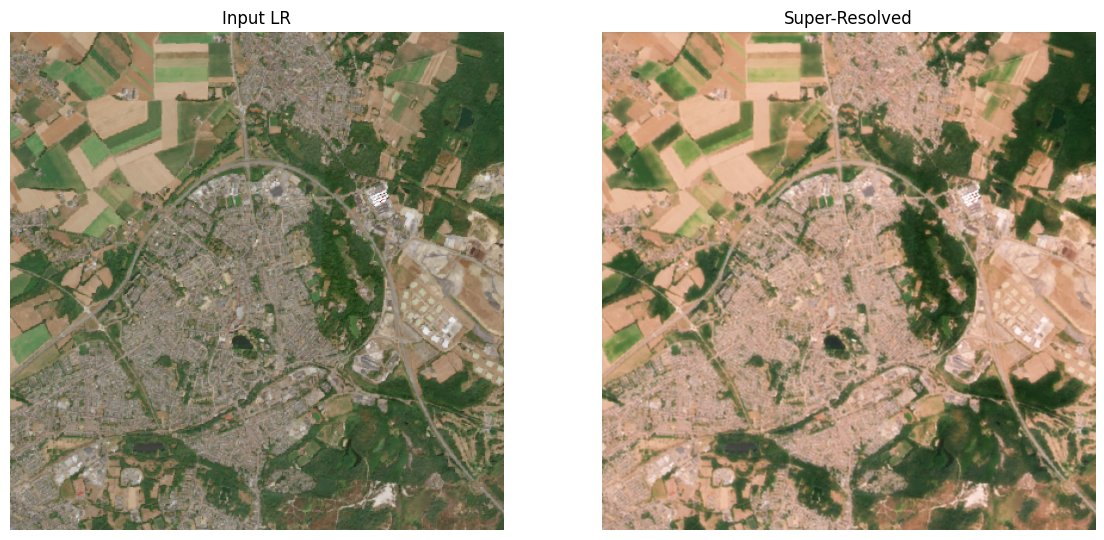

In [7]:
lr, sr = super_resolve('/kaggle/input/datasets/satvikvarshney73/input-dataset/converted.tiff')

fig, axes = plt.subplots(1, 2, figsize=(14,7))
axes[0].imshow(np.transpose(lr, (1,2,0))); axes[0].set_title("Input LR"); axes[0].axis('off')
axes[1].imshow(np.transpose(sr, (1,2,0))); axes[1].set_title("Super-Resolved"); axes[1].axis('off')
plt.show()